# Problem Statement:
Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola.
Churn among drivers is high and it’s very easy for drivers to stop working for the service on
the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new
drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this
acquisition is costly. Losing drivers frequently impacts the morale of the organization and
acquiring new drivers is more expensive than retaining existing ones.

## Column Profiling:
1. MMMM-YY : Reporting Date (Monthly)
2. Driver_ID : Unique id for drivers
3. Age : Age of the driver
4. Gender : Gender of the driver – Male : 0, Female: 1
5. City : City Code of the driver
6. Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
7. Income : Monthly average Income of the driver
8. Date Of Joining : Joining date for the driver
9. LastWorkingDate : Last date of working for the driver
10. Joining Designation : Designation of the driver at the time of joining
11. Grade : Grade of the driver at the time of reporting
12. Total Business Value : The total business value acquired by the driver in a month
(negative business indicates cancellation/refund or car EMI adjustments)
13. Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

# Import the necessary libraries & Basic Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv")

In [ ]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


# Exploratory Data Analysis

In [ ]:
df.shape

(19104, 14)

- The DataSet Contains 19104 rows and 14 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [ ]:
# check unique values in categorical variables
for col in df:
    print("Column:  {:18}   Unique values: {}".format(col, df[col].nunique()))

Column:  Unnamed: 0           Unique values: 19104
Column:  MMM-YY               Unique values: 24
Column:  Driver_ID            Unique values: 2381
Column:  Age                  Unique values: 36
Column:  Gender               Unique values: 2
Column:  City                 Unique values: 29
Column:  Education_Level      Unique values: 3
Column:  Income               Unique values: 2383
Column:  Dateofjoining        Unique values: 869
Column:  LastWorkingDate      Unique values: 493
Column:  Joining Designation   Unique values: 5
Column:  Grade                Unique values: 5
Column:  Total Business Value   Unique values: 10181
Column:  Quarterly Rating     Unique values: 4


In [ ]:
df.describe()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [ ]:
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

**Separating Numerical variables and Categorical variables.**

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].astype('category')

**Making the target variable based on the leaving date of the driver**

In [ ]:
df['LastWorkingDate'].isna().sum()

np.int64(17488)

In [ ]:
df['Target'] = df['LastWorkingDate'].apply(lambda x: 0 if pd.notna(x) else
1)
df.drop('LastWorkingDate', axis = 1, inplace = True)
df['Target'].value_counts()

,count
Target,
1,17488
0,1616


**As the Unnamed 0 Column is not providing any useful information so dropping it.**

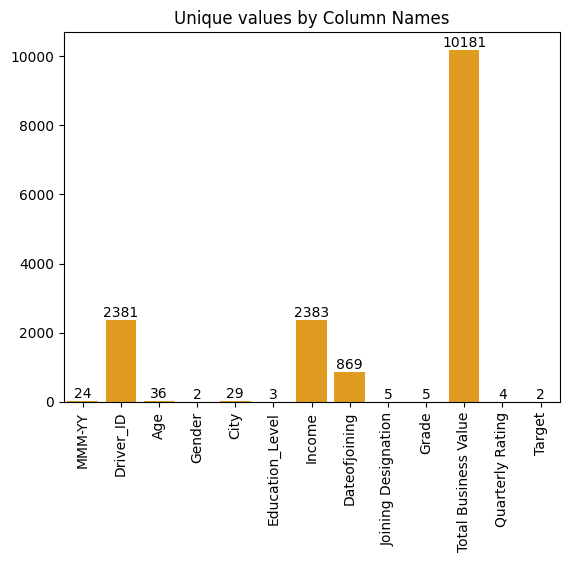

In [ ]:
# Removing the unwanted field 'Unnamed : 0
df.drop('Unnamed: 0',axis = 1,inplace=True)

# Checking the unique count in each column and total count
col_name = [cols for cols in df.columns]
unique_count = [df[cols].nunique() for cols in df.columns]

gr = sns.barplot(y = unique_count,x = col_name,color='orange')
gr.bar_label(gr.containers[0])
plt.title('Unique values by Column Names')
plt.xticks(rotation = 90)
plt.show()

**Missing value detection**

In [ ]:
df.isnull().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
Joining Designation,0
Grade,0


- There are 61 missing values in Age column and 52 missing values in Gender column

## Univariate Data Analysis

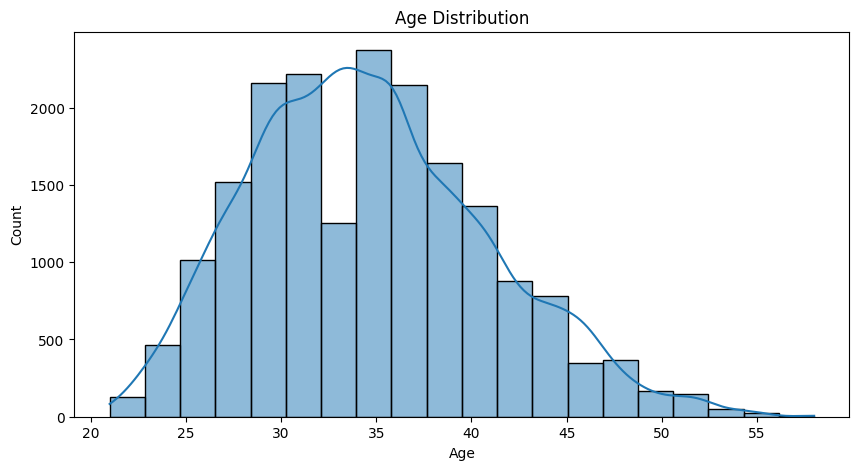

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

- The dataset is dominated by young to mid-age employees (25–40) with a peak around early 30s, and very few older employees.

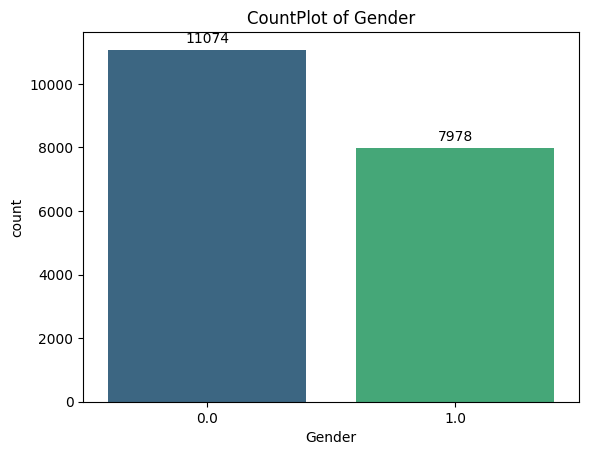

In [ ]:
ax = sns.countplot(data = df,x = df['Gender'],hue = 'Gender',palette='viridis',legend=False)
for container in ax.containers:
  ax.bar_label(container,padding = 3)
plt.title("CountPlot of Gender")
plt.show()

- There are 11074 males and 7978 females

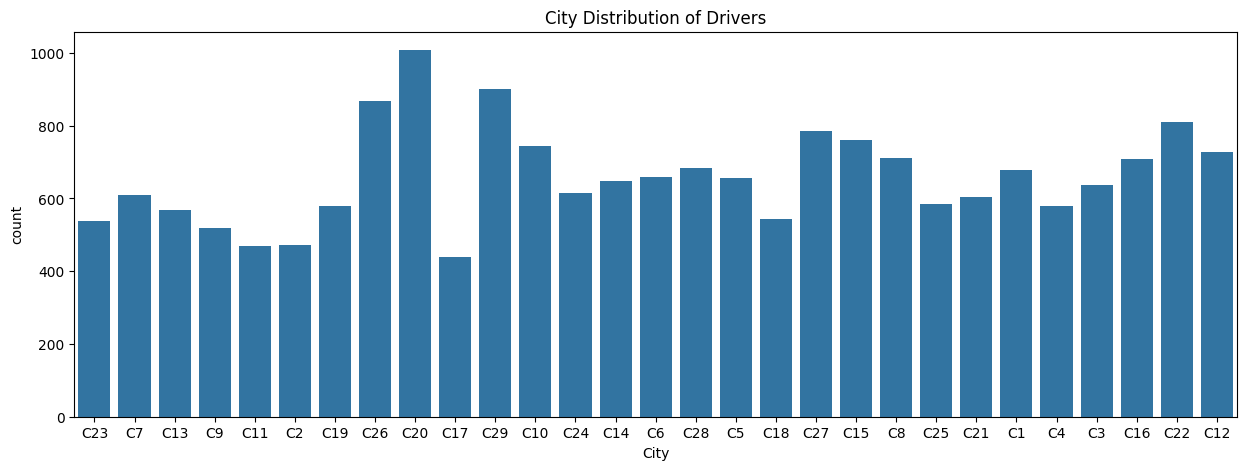

In [ ]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="City");
plt.title("City Distribution of Drivers");

- We can see that C20 has the highest number of drivers

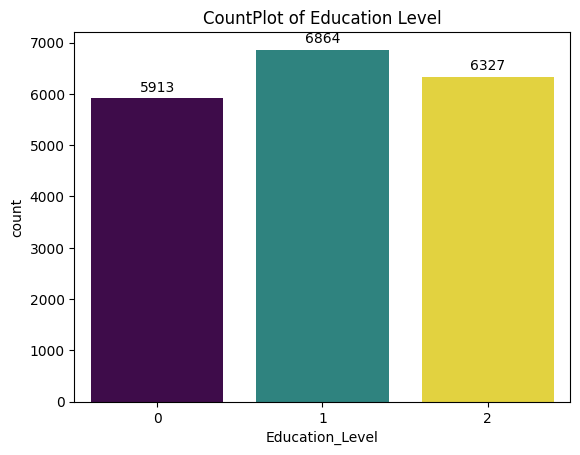

In [ ]:
ax = sns.countplot(data = df,x = df['Education_Level'],hue = 'Education_Level',palette='viridis',legend=False)
for container in ax.containers:
  ax.bar_label(container,padding = 3)
plt.title("CountPlot of Education Level")
plt.show()

- Majority of the group are (12+)
- Graduates is the second largest group

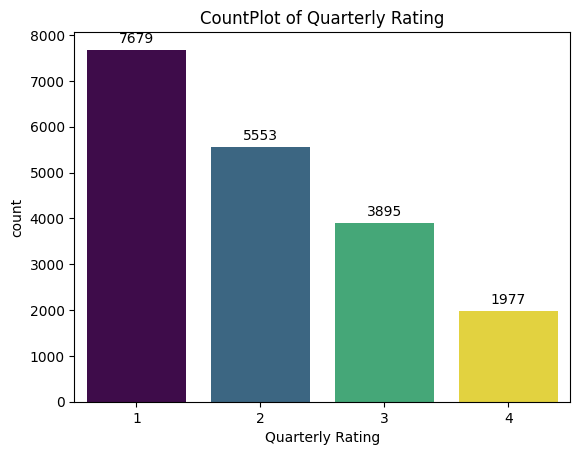

In [ ]:

ax = sns.countplot(data = df,x = df['Quarterly Rating'],hue = 'Quarterly Rating',palette='viridis',legend=False)
for container in ax.containers:
  ax.bar_label(container,padding = 3)
plt.title("CountPlot of Quarterly Rating")
plt.show()

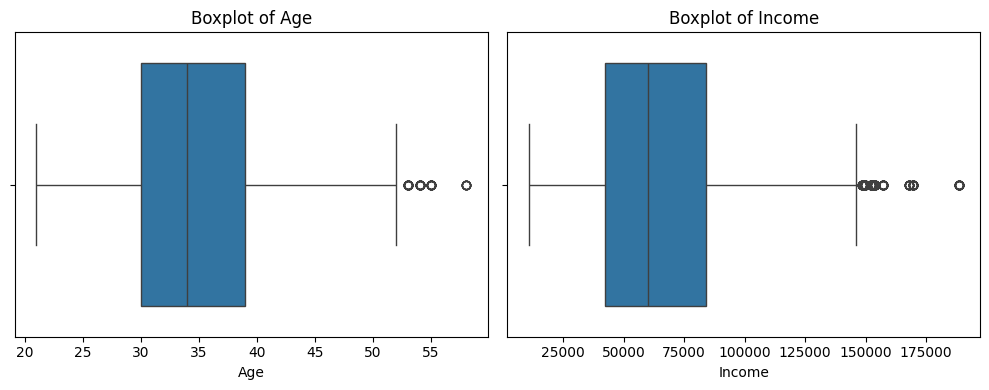

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x = df['Age'], ax=axs[0])
axs[0].set_title("Boxplot of Age")

sns.boxplot(x = df['Income'],ax=axs[1])
axs[1].set_title("Boxplot of Income")

plt.tight_layout()
plt.show()

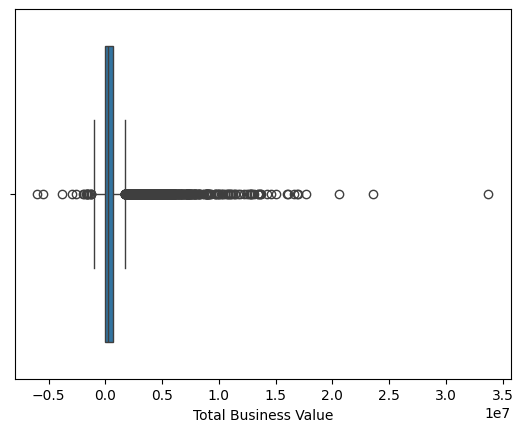

In [ ]:
sns.boxplot(x = df['Total Business Value'])
plt.show()

Key takeaways :
1. Median age is around mid-30s, with most employees between 30–40
Few older outliers (50+), indicating limited senior-age workforce
2. Income is right-skewed → most employees earn in lower-mid range
Presence of high-income outliers, likely senior/top performers
3. Total Business Value
Extremely right-skewed with heavy outliers
Most values are clustered near low range, but few employees generate very high business value

## Bi-variate Analysis

### categorical-continuous variables

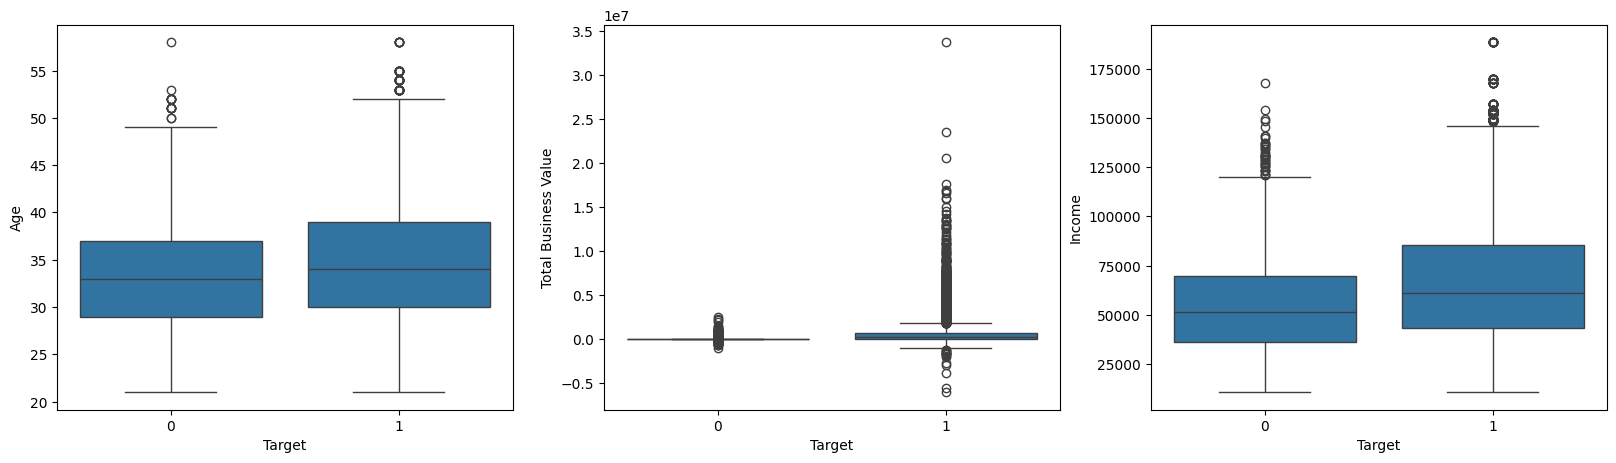

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df, x="Target", y="Age", ax=ax[0]);
sns.boxplot(data=df, x="Target", y="Total Business Value", ax=ax[1]);
sns.boxplot(data=df, x="Target", y="Income", ax=ax[2]);

<b style='padding: 4px 10px 6px 10px;border-radius: 5px;background: #009688;color: #fff;display: inline-block;'>Observations</b>

- Above plots show how different features affect the target variable
- We can see the Income, Age business value and total business value is less for churned drivers.

/tmp/ipykernel_784/3306298549.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  gr = sns.barplot(x = education_level, y = value, hue = target, color =


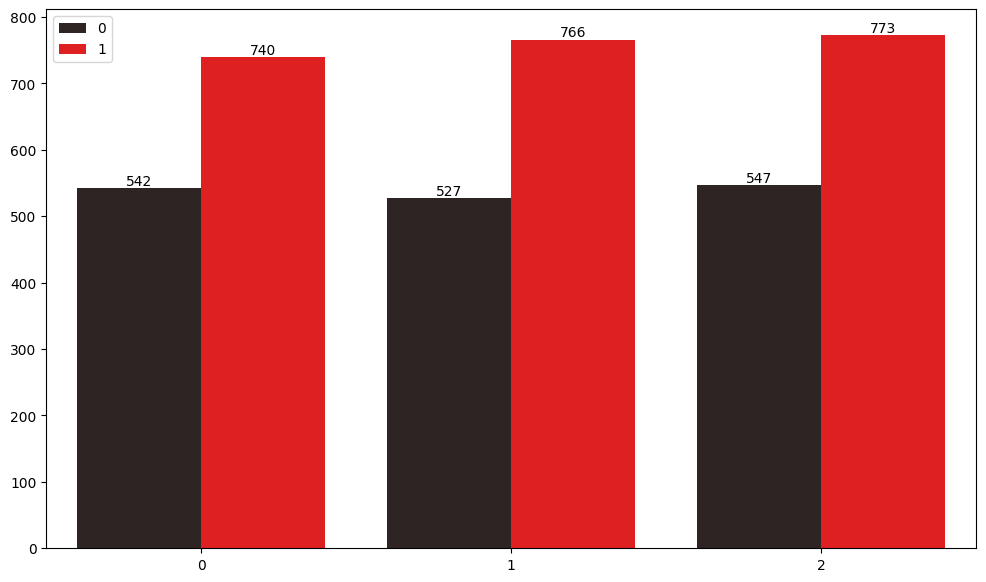

In [ ]:
#Here Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
data = df.groupby(['Education_Level','Target'])['Driver_ID'].agg('nunique')
# plotting the graph
education_level = [tuple[0] for tuple in data.index]
target = [tuple[1] for tuple in data.index]
value = data.values
#plotting the graph
plt.figure(figsize = (12,7))
gr = sns.barplot(x = education_level, y = value, hue = target, color =
'red')
gr.bar_label(gr.containers[0])
gr.bar_label(gr.containers[1])
plt.show()

- The proportion between chruned and not chruned are almost same for all the Education Levels

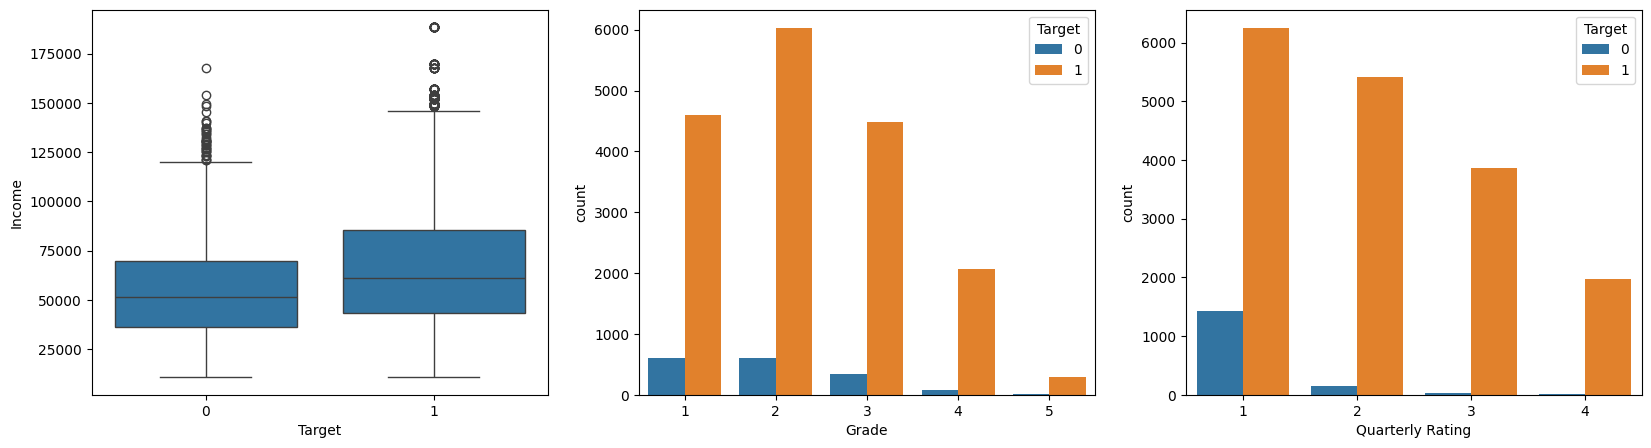

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
sns.boxplot(data=df, x="Target", y="Income", ax=ax[0]);
sns.countplot(data=df, x="Grade", hue="Target", ax=ax[1]);
sns.countplot(data=df, x="Quarterly Rating", hue="Target", ax=ax[2]);

<b style='padding: 4px 10px 6px 10px;border-radius: 5px;background: #009688;color: #fff;display: inline-block;'>Observations</b>
- We can see that Income is less for churned drivers as compared to current drivers.
- Low Income may be responsible for driver churn.
- There are very few Grade 4 and 5 employees as compared to Grade 1, 2 and 3.
- Majority of the drivers churning belong to Grade 1 and 2.
- Majority of the drivers who Churned had 1 rating.

### categorical-categorical Variables

**Ratio of Churned drivers by City**

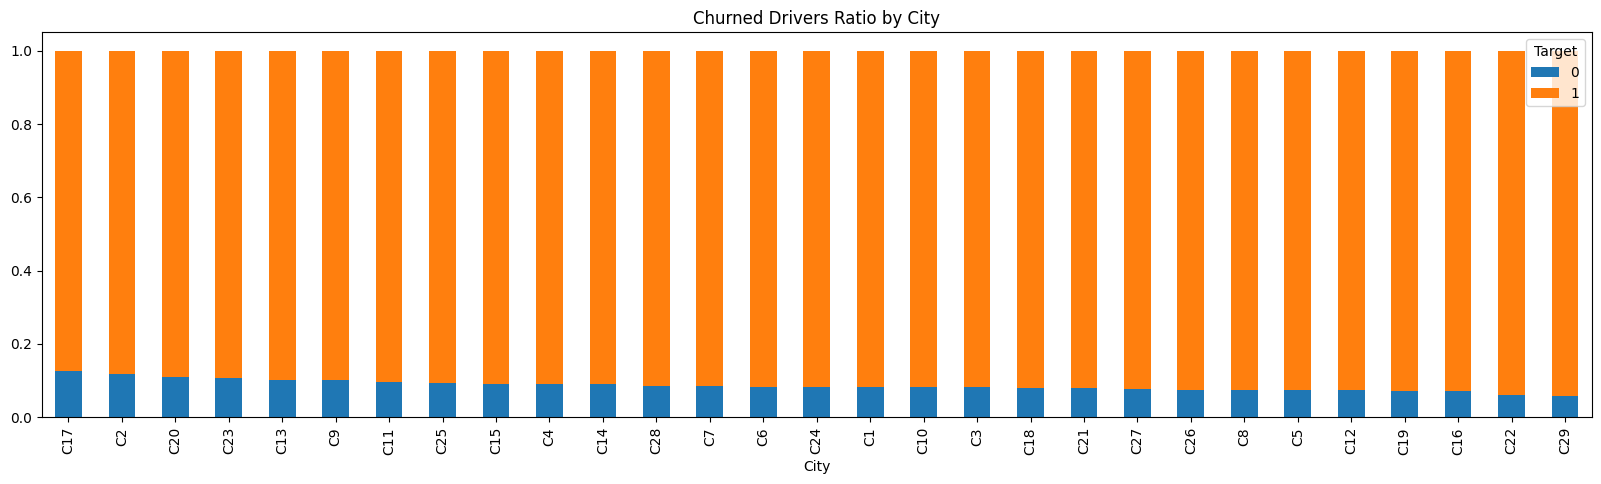

In [ ]:
pd.crosstab(df["City"], df["Target"],  normalize="index").sort_values(1).plot(kind="bar", stacked=True, figsize=(20, 5));
plt.title("Churned Drivers Ratio by City");

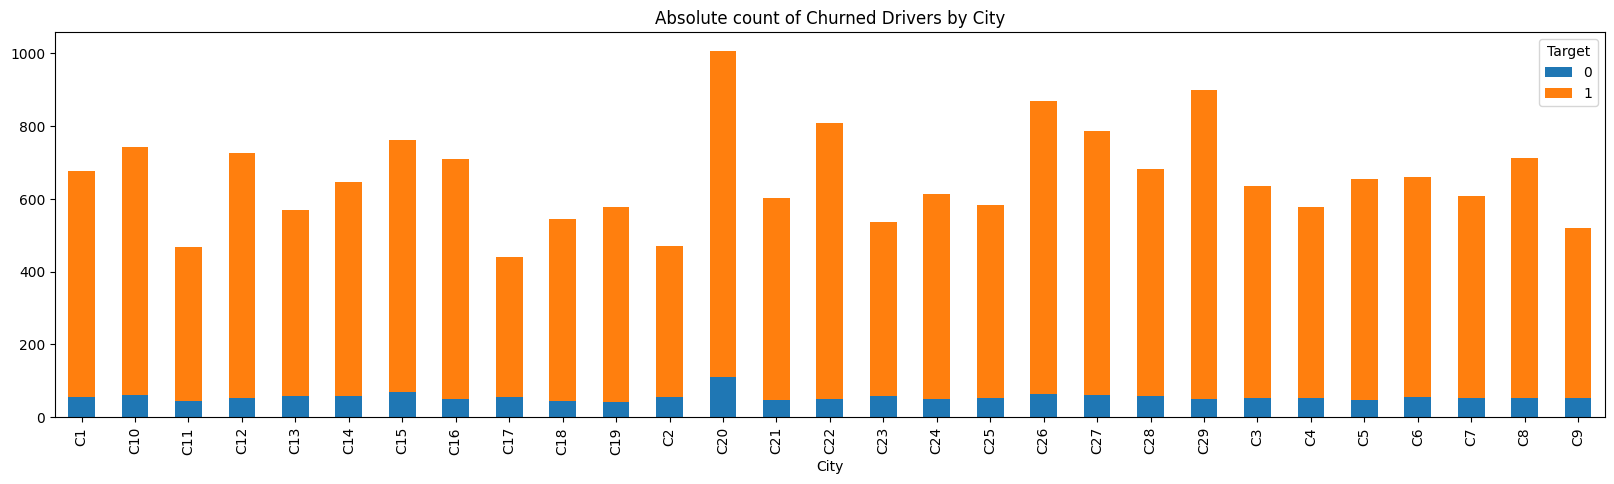

In [ ]:
pd.crosstab(df["City"], df["Target"]).plot(kind="bar", stacked=True, figsize=(20, 5));
plt.title("Absolute count of Churned Drivers by City");

<b style='padding: 4px 10px 6px 10px;border-radius: 5px;background: #009688;color: #fff;display: inline-block;'>Observations</b>

- Above plot shows the ratio of churned drivers in each city
- C13 have highest ratio of Churned drivers
- C29 have the lowest ratio of Churned drivers
- C20 had highest number of Churned drivers

**Revenue Distribution by City**

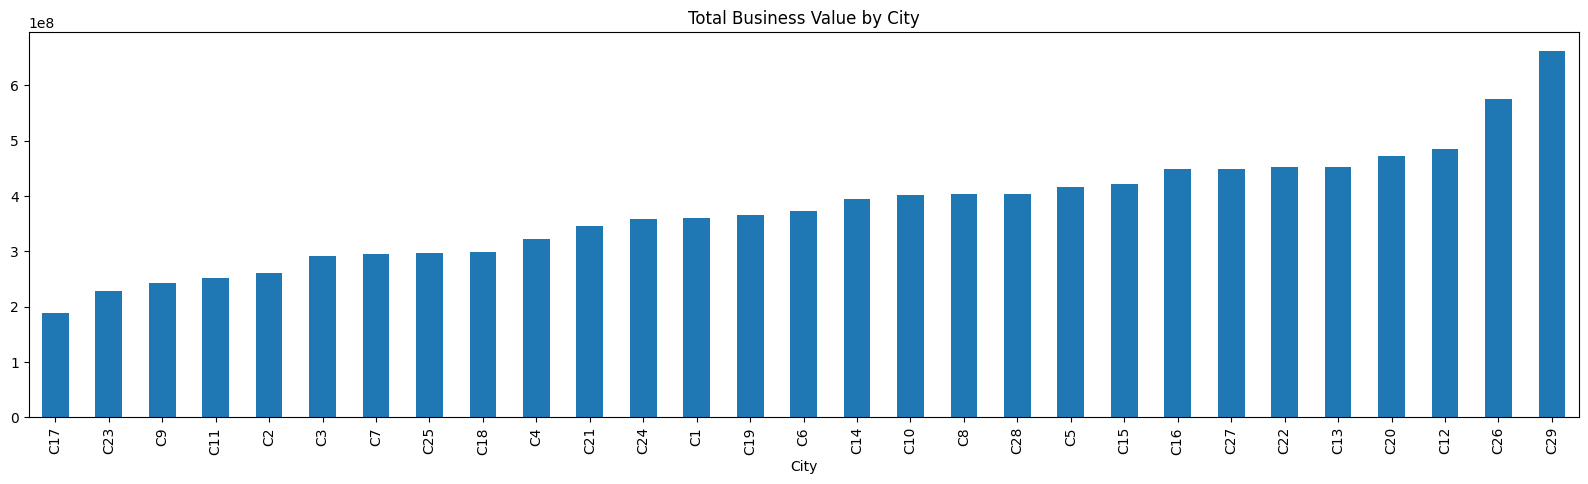

In [ ]:
df.groupby("City")["Total Business Value"].sum().sort_values().plot(kind="bar", figsize=(20, 5));
plt.title("Total Business Value by City");

<b style='padding: 4px 10px 6px 10px;border-radius: 5px;background: #009688;color: #fff;display: inline-block;'>Observations</b>
- City C29 makes the Highest revenue amongst all other cities

### continuous-continuous variables

<Axes: xlabel='Income', ylabel='Total Business Value'>

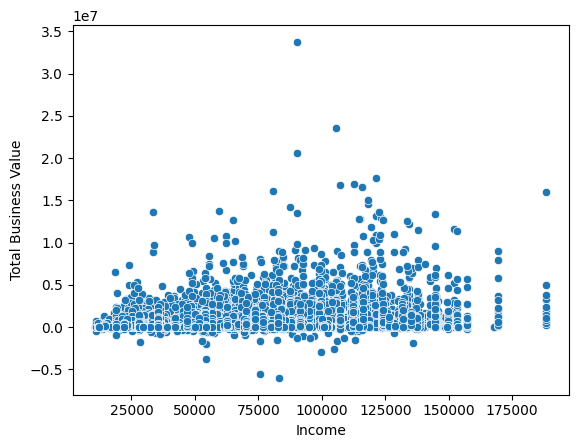

In [ ]:
sns.scatterplot(x='Income', y='Total Business Value', data=df)

- No strong linear trend → higher income does not guarantee higher business value
- For similar income levels, business value varies a lot
- Indicates performance depends on other factors (not just salary)
- Few points with very high business value → top performers
Some negative values → underperformers
- Most employees are concentrated in:

  + Income: 30K–120K
  + Business value: low to moderate range

<Axes: xlabel='Income', ylabel='Age'>

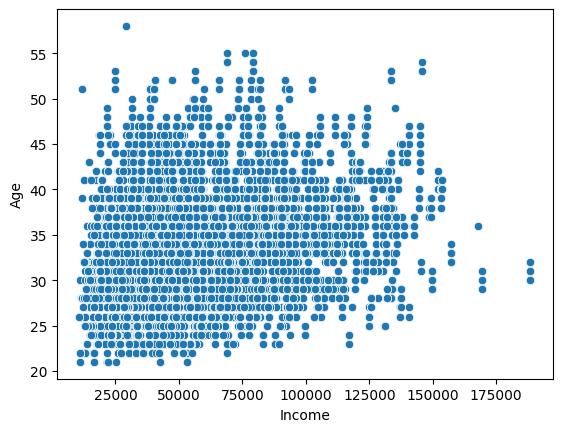

In [ ]:
sns.scatterplot(x='Income', y='Age', data=df)

- The ScatterPlot between Age and Income indicates that there is no particular pattern but the majority of the income is between 25000 to 125000

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Target
Driver_ID,1.000000,0.005457,0.030349,-0.016132,-0.035767,-0.035166,-0.025712,0.003896,0.017917,0.000675
Age,0.005457,1.000000,0.040261,-0.010245,0.191112,-0.006641,0.210702,0.108835,0.171818,0.063562
Gender,0.030349,0.040261,1.000000,-0.010123,0.013229,-0.050878,0.002076,0.008909,0.008099,0.002908
Education_Level,-0.016132,-0.010245,-0.010123,1.000000,0.115008,0.002041,-0.039552,-0.007504,0.026064,0.007058
Income,-0.035767,0.191112,0.013229,0.115008,1.000000,0.380878,0.778383,0.234044,0.116897,0.100896
Joining Designation,-0.035166,-0.006641,-0.050878,0.002041,0.380878,1.000000,0.559854,-0.044446,-0.237791,-0.020249
Grade,-0.025712,0.210702,0.002076,-0.039552,0.778383,0.559854,1.000000,0.220955,0.014445,0.089486
Total Business Value,0.003896,0.108835,0.008909,-0.007504,0.234044,-0.044446,0.220955,1.000000,0.471224,0.142921
Quarterly Rating,0.017917,0.171818,0.008099,0.026064,0.116897,-0.237791,0.014445,0.471224,1.000000,0.260493
Target,0.000675,0.063562,0.002908,0.007058,0.100896,-0.020249,0.089486,0.142921,0.260493,1.000000


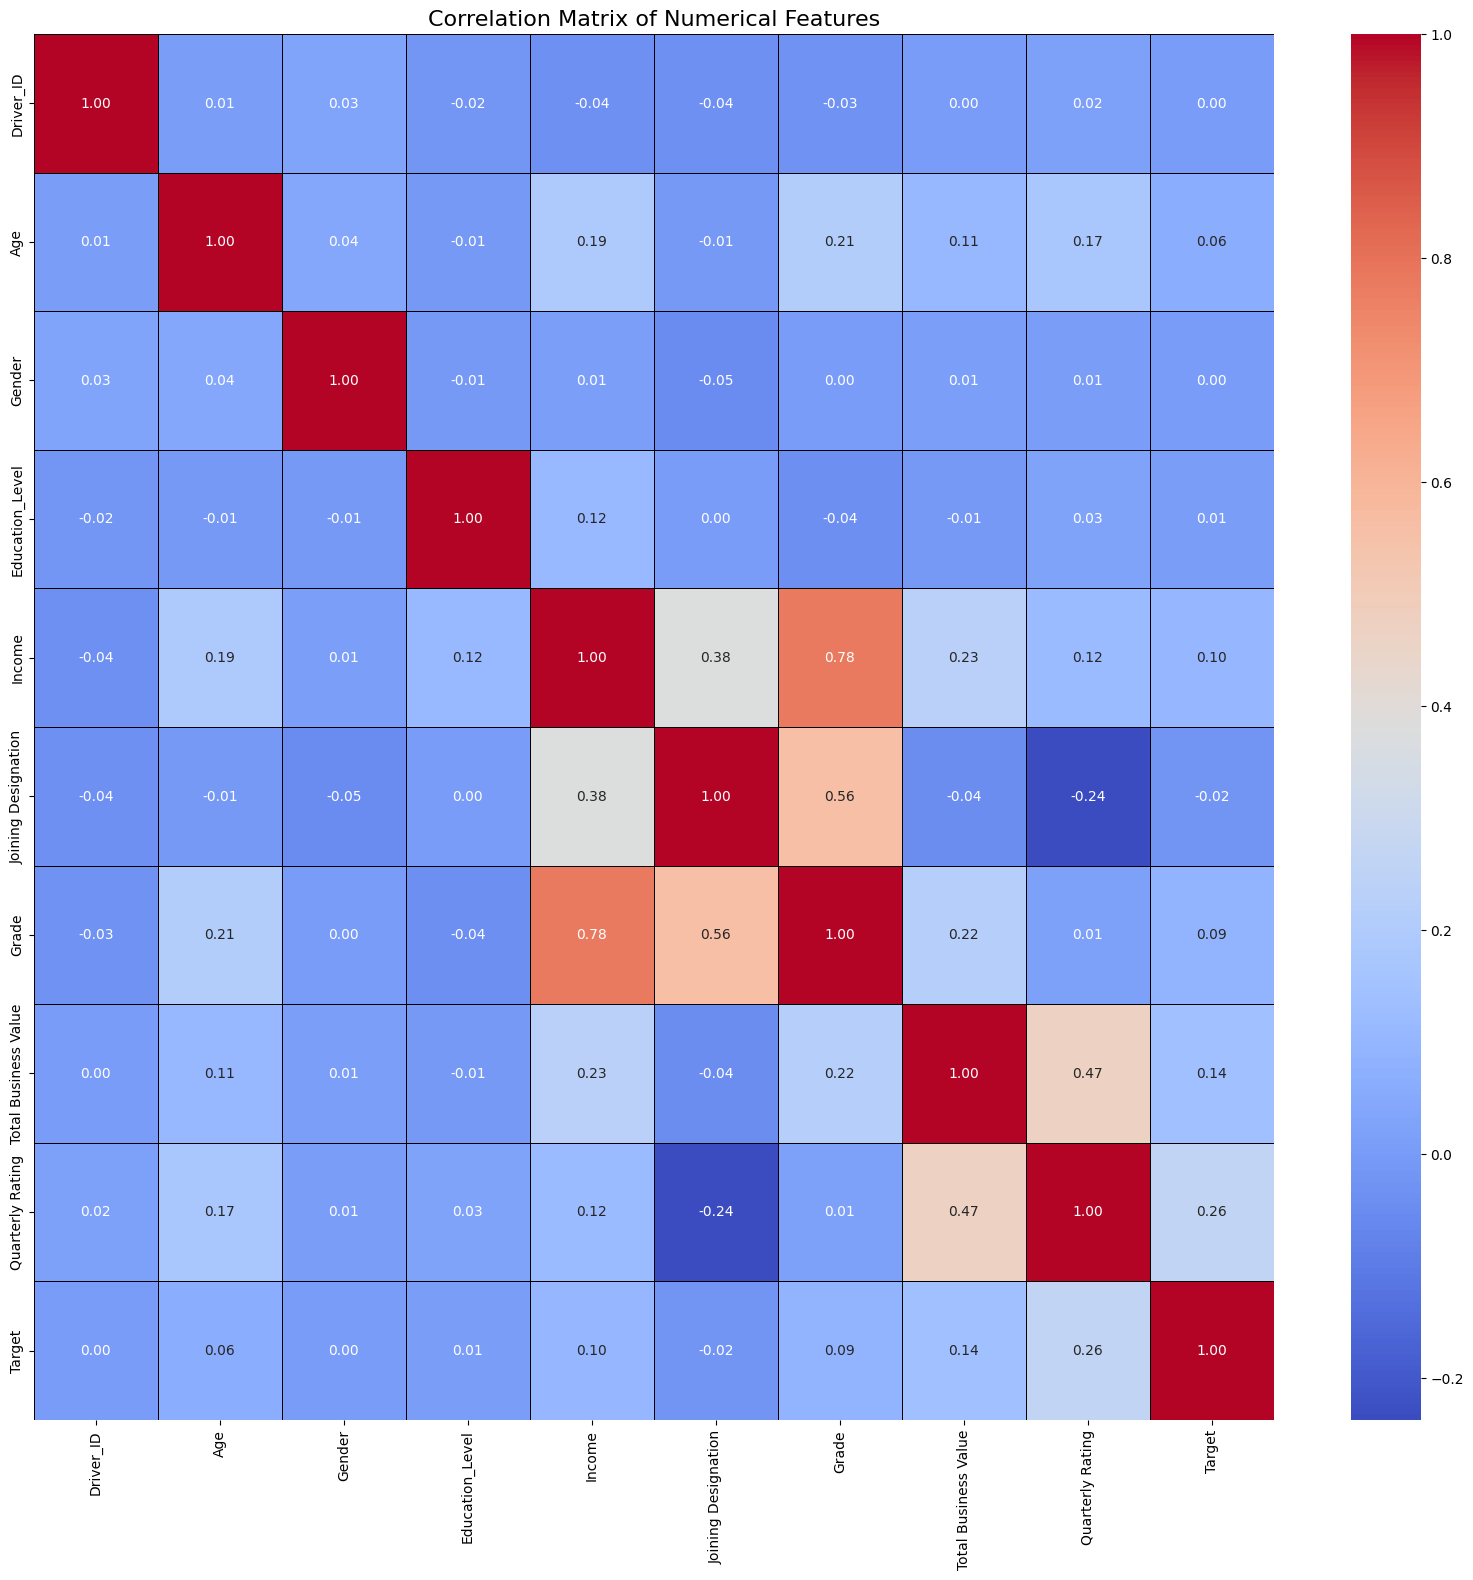

In [ ]:
plt.figure(figsize=(20, 18))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, linecolor='black', annot_kws={'size': 10})
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

**Insights:**
- **Quarterly Rating is the Strongest Predictor of Retention:** 'Quarterly Rating' shows the highest positive correlation with 'Target' (0.26). This suggests that drivers with higher quarterly ratings are significantly more likely to be retained.
- **Total Business Value and Income Influence Retention:** 'Total Business Value' (0.14) and 'Income' (0.10) also have positive correlations with 'Target'. Drivers who generate more business value and earn higher incomes tend to be more retained.
- **Age and Grade have a Modest Impact on Retention:** 'Age' (0.06) and 'Grade' (0.09) show small positive correlations with 'Target', indicating that older drivers and those with higher grades are slightly more likely to be retained.
- **Strong Relationship Between Grade, Income, and Joining Designation:** There's a very strong positive correlation between 'Income' and 'Grade' (0.78), and strong positive correlations between 'Joining Designation' with 'Income' (0.38) and 'Grade' (0.56). This implies that higher grades and joining designations are associated with higher incomes.
- **Total Business Value Linked to Quarterly Rating:** 'Total Business Value' has a moderate positive correlation with 'Quarterly Rating' (0.47), suggesting that higher-rated drivers tend to bring in more business.
- **Weak Influence on Retention:** 'Education_Level', 'Gender', and 'Joining Designation' show very weak or negligible correlations with 'Target', indicating they are not strong individual indicators of driver churn or retention.

# Data Preprocessing

### Outliers Detection

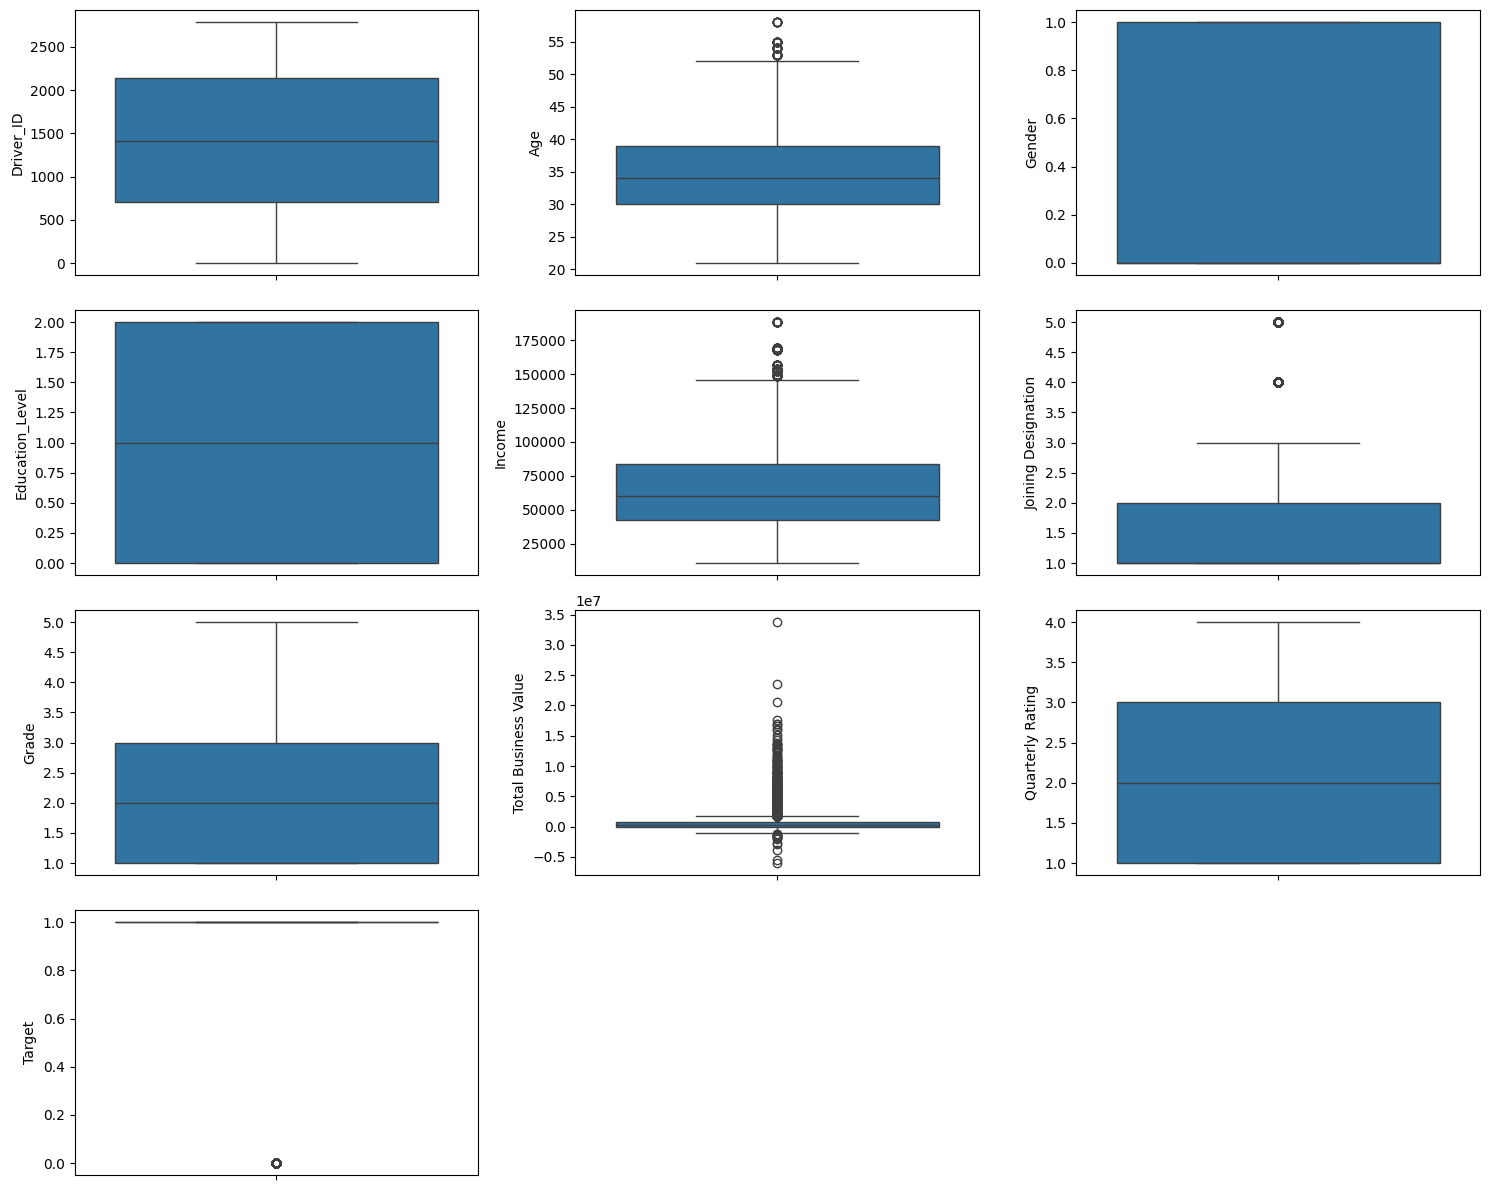

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(15, 12))

# Re-evaluate num_cols to reflect the current state of df
num_cols1 = df.select_dtypes(include=['int64','float64']).columns.tolist()

for i, col in enumerate(num_cols1):
    # Ensure we don't try to plot more than we have space for if num_cols < 12
    if i < ax.size:
        sns.boxplot(df[col], ax=ax.flatten()[i])

# Hide any unused subplots
for j in range(len(num_cols), ax.size):
    fig.delaxes(ax.flatten()[j])

plt.tight_layout();

**Insights from Box Plots:**

1.  **Age Distribution:**
    *   The box plot for 'Age' shows that the majority of drivers are concentrated in the young to mid-age range, typically between 25 and 40 years. The median age is around the mid-30s. There are a few outliers on the higher end, indicating a small number of older drivers.

2.  **Income Distribution:**
    *   The 'Income' box plot confirms a right-skewed distribution, with the bulk of drivers earning in the lower to mid-range. There is a significant presence of high-income outliers, suggesting a few drivers with considerably higher earnings than the rest.

3.  **Total Business Value Distribution:**
    *   'Total Business Value' exhibits an extremely right-skewed distribution with numerous outliers on both the positive and negative ends. Most values are clustered near the lower range, indicating that while many drivers generate moderate business, a small number contribute exceptionally high business value, and some have significantly negative values (due to cancellations/refunds).

4.  **Categorical Variables (Driver_ID, Education_Level, Joining Designation, Grade, Quarterly Rating, Target):**
    *   For variables like 'Driver_ID', 'Education_Level', 'Joining Designation', 'Grade', 'Quarterly Rating', and 'Target', which are inherently categorical or identifiers (despite having numerical data types), box plots are generally not the most appropriate visualization. Their box plots primarily show discrete points or narrow distributions, and any 'outliers' often reflect less frequent categories rather than true numerical anomalies. For these, count plots or bar plots would provide clearer insights into their distribution and frequencies.

In [ ]:
print('--- Outlier Detection using IQR Method ---')

outlier_summary = {}

# Re-evaluate num_cols to reflect the current state of df
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': num_outliers,
        'Percentage of Outliers': (num_outliers / df.shape[0]) * 100
    }

    if num_outliers > 0:
        print(f"Column '{col}': {num_outliers} outliers detected ({outlier_summary[col]['Percentage of Outliers']:.2f}%)")
    else:
        print(f"Column '{col}': No outliers detected.")

# You can also display a more detailed summary if needed
# for col, data in outlier_summary.items():
#     print(f"\nColumn: {col}")
#     for key, value in data.items():
#         print(f"  {key}: {value}")

--- Outlier Detection using IQR Method ---
Column 'Driver_ID': No outliers detected.
Column 'Age': 78 outliers detected (0.41%)
Column 'Gender': No outliers detected.
Column 'Education_Level': No outliers detected.
Column 'Income': 188 outliers detected (0.98%)
Column 'Joining Designation': 471 outliers detected (2.47%)
Column 'Grade': No outliers detected.
Column 'Total Business Value': 1371 outliers detected (7.18%)
Column 'Quarterly Rating': No outliers detected.
Column 'Target': 1616 outliers detected (8.46%)


**Observations on Outliers using IQR Method:**

Based on the IQR method (1.5 * IQR rule), here's an overview of the detected outliers:

-   **Age:** Some outliers were detected, likely on the higher end, indicating a few drivers significantly older than the majority. This aligns with the visual observation from the box plot.
-   **Gender:** Being a binary categorical variable (0 or 1), 'Gender' does not typically have outliers in the statistical sense for continuous data. Any 'outliers' detected would likely be due to a very imbalanced distribution or data entry errors, rather than extreme continuous values. However, given its float dtype and the method applied, it might show a spurious count if the distribution is skewed and the bounds fall outside the 0-1 range.
-   **Income:** A significant number of outliers are present, especially on the higher end. This confirms the right-skewed distribution and the presence of high-income earners as observed in its box plot.
-   **Total Business Value:** This column shows a very high number of outliers, present on both the negative (cancellations/refunds) and extremely positive ends. This confirms the highly skewed nature and the large variance in business value generation, with some drivers having exceptionally high or low values.
-   **Quarterly Rating:** As an ordinal categorical variable (1, 2, 3, 4, 5), 'Quarterly Rating' might show 'outliers' if certain ratings are extremely rare. The IQR method might flag ratings that are infrequent as outliers, though these are typically handled as distinct categories rather than continuous anomalies.

**Variables that are less prone to meaningful 'outliers' by IQR due to their nature (categorical/identifier):**
-   **Driver_ID:** This is a unique identifier, and thus each value is distinct. Applying IQR to it is not meaningful for outlier detection.
-   **Education_Level, Joining Designation, Grade:** These are ordinal categorical variables. While the IQR method can technically be applied, 'outliers' here would usually indicate less frequent categories rather than data anomalies that need treatment like continuous data.

 **Visualizing Skewness of Continuous Variables**

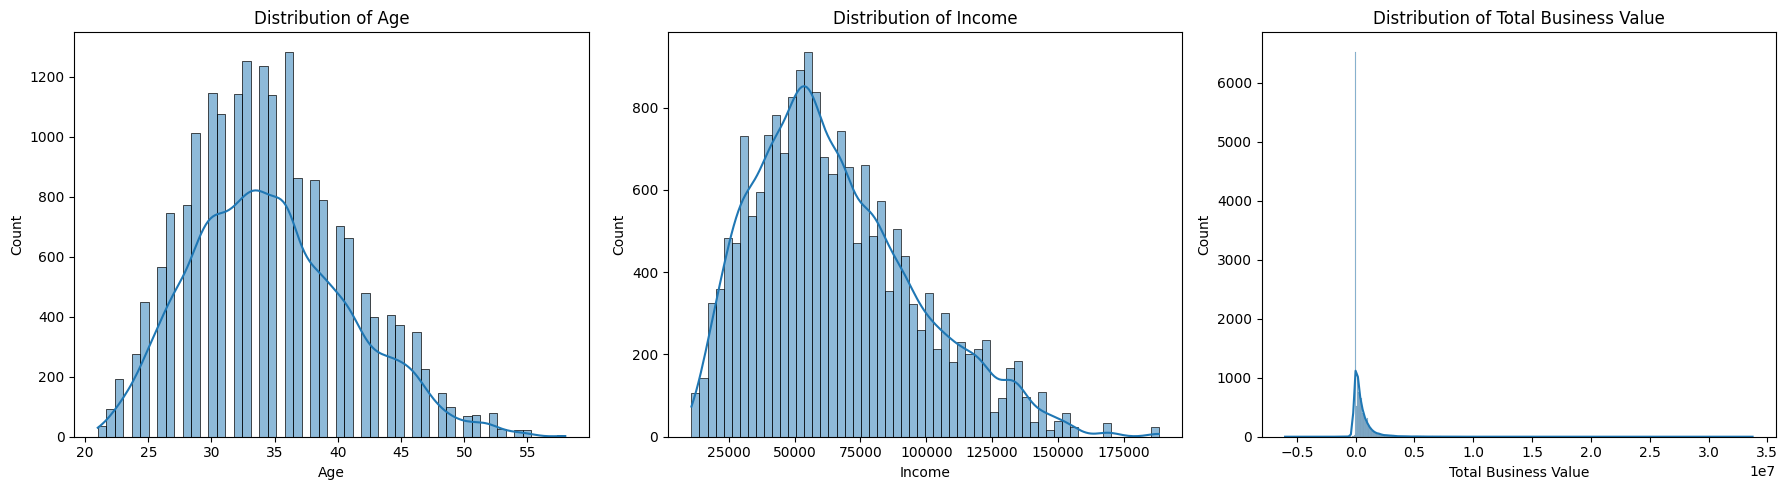

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='Age', kde=True, ax=axs[0])
axs[0].set_title('Distribution of Age')

sns.histplot(data=df, x='Income', kde=True, ax=axs[1])
axs[1].set_title('Distribution of Income')

sns.histplot(data=df, x='Total Business Value', kde=True, ax=axs[2])
axs[2].set_title('Distribution of Total Business Value')

plt.tight_layout()
plt.show()

**Skewness of Continuous Variables:**

*   **Age:** The distribution of 'Age' appears to be relatively symmetric, with a slight right-skew. The majority of drivers are in the young to mid-age range (25-40), with a peak around early 30s. The box plot confirms the presence of a few older outliers but the overall distribution is not heavily skewed.

*   **Income:** 'Income' exhibits a clear **right-skewed** distribution. Most drivers earn in the lower to mid-range, with a longer tail extending towards higher incomes, indicating a smaller number of high-earning drivers. This was evident in both the histogram and box plot, with numerous high-income outliers.

*   **Total Business Value:** 'Total Business Value' is **highly right-skewed**. The majority of values are clustered near the low end (including zero and negative values), but there's a very long tail of extremely high positive values. The box plot showed a dense cluster at the lower end and a significant number of extreme positive outliers, along with some negative values representing cancellations or refunds.



## Duplicate value check

In [ ]:
df.duplicated().sum()

np.int64(0)

- There are no duplicates

## Converting features to respective data-types

In [ ]:
df["MMM-YY"] = pd.to_datetime(df["MMM-YY"])
df["Dateofjoining"] = pd.to_datetime(df["Dateofjoining"])

/tmp/ipykernel_784/3668570738.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["MMM-YY"] = pd.to_datetime(df["MMM-YY"])
/tmp/ipykernel_784/3668570738.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dateofjoining"] = pd.to_datetime(df["Dateofjoining"])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   Joining Designation   19104 non-null  int64         
 9   Grade                 19104 non-null  int64         
 10  Total Business Value  19104 non-null  int64         
 11  Quarterly Rating      19104 non-null  int64         
 12  Target                19104 non-null  int64         
dtypes: datetime64[ns

## Missing value treatment

### Check for missing values and Prepare data for KNN Imputation

In [ ]:
df.isnull().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
Joining Designation,0
Grade,0


- Only Age and Gender Features has missing values

In [ ]:
num_vars = df.select_dtypes(np.number)

num_vars.columns

Index(['Driver_ID', 'Age', 'Gender', 'Education_Level', 'Income',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating', 'Target'],
      dtype='object')

In [ ]:
num_vars.drop(["Driver_ID"], axis = 1, inplace = True)

### imputing the missing values using KNN imputer

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')
imputer.fit(num_vars)
data_new = imputer.transform(num_vars)

In [ ]:
data_new = pd.DataFrame(data_new)

In [ ]:
data_new.columns = num_vars.columns

In [ ]:
data_new.isnull().sum()

,0
Age,0
Gender,0
Education_Level,0
Income,0
Joining Designation,0
Grade,0
Total Business Value,0
Quarterly Rating,0
Target,0


- After the KNN imputation, There is no null values

**Concatenating dataframes**

In [ ]:
resultant_columns = list(set(df.columns).difference(set(num_vars)))

resultant_columns

['City', 'MMM-YY', 'Driver_ID', 'Dateofjoining']

In [ ]:
new_df = pd.concat([data_new, df[resultant_columns]], axis=1)

new_df.shape

(19104, 13)

In [ ]:
new_df.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Target,City,MMM-YY,Driver_ID,Dateofjoining
0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0,1.0,C23,2019-01-01,1,2018-12-24
1,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0,1.0,C23,2019-02-01,1,2018-12-24
2,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0,0.0,C23,2019-03-01,1,2018-12-24
3,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,1.0,C7,2020-11-01,2,2020-11-06
4,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,1.0,C7,2020-12-01,2,2020-11-06


## Feature Enginnering

In [ ]:
agg_functions = {
    "Age": "max",
    "Gender": "first",
    "Education_Level": "last",
    "Income": "last",
    "Joining Designation": "last",
    "Grade": "last",
    "Total Business Value": "sum",
    "Quarterly Rating": "last",
    "City": "first",
    "Dateofjoining": "last",
    "Target" : "last"
}

processed_df = new_df.groupby(["Driver_ID", "MMM-YY"]).aggregate(agg_functions).sort_index(ascending = [True, True])

processed_df.head()

Age  Gender  Education_Level   Income  \
Driver_ID MMM-YY                                               
1         2019-01-01  28.0     0.0              2.0  57387.0   
          2019-02-01  28.0     0.0              2.0  57387.0   
          2019-03-01  28.0     0.0              2.0  57387.0   
2         2020-11-01  31.0     0.0              2.0  67016.0   
          2020-12-01  31.0     0.0              2.0  67016.0   

                      Joining Designation  Grade  Total Business Value  \
Driver_ID MMM-YY                                                         
1         2019-01-01                  1.0    1.0             2381060.0   
          2019-02-01                  1.0    1.0             -665480.0   
          2019-03-01                  1.0    1.0                   0.0   
2         2020-11-01                  2.0    2.0                   0.0   
          2020-12-01                  2.0    2.0                   0.0   

                      Quarterly Rating City Dateofjoining  Target  
Driver_ID MMM-YY                                                   
1         2019-01-01               2.0  C23    2018-12-24     1.0  
          2019-02-01               2.0  C23    2018-12-24     1.0  
          2019-03-01               2.0  C23    2018-12-24     0.0  
2         2020-11-01               1.0   C7    2020-11-06     1.0  
          2020-12-01               1.0   C7    2020-11-06     1.0

This cell defines aggregation functions and groups the data by `Driver_ID` and `MMM-YY` to create `processed_df`, which aggregates monthly data per driver.


In [ ]:
final_data = pd.DataFrame()

This cell initializes an empty DataFrame named `final_data` to store the engineered features.

In [ ]:
final_data["Driver_ID"] = new_df["Driver_ID"].unique()

This cell populates the `Driver_ID` column in `final_data` with unique driver identifiers.

In [ ]:
final_data['Age'] = list(processed_df.groupby('Driver_ID',axis=0).max('MMM-YY')['Age'])
final_data['Gender'] = list(processed_df.groupby('Driver_ID').agg({'Gender':'last'})['Gender'])
final_data['City'] = list(processed_df.groupby('Driver_ID').agg({'City':'last'})['City'])
final_data['Education'] = list(processed_df.groupby('Driver_ID').agg({'Education_Level':'last'})['Education_Level'])
final_data['Income'] = list(processed_df.groupby('Driver_ID').agg({'Income':'last'})['Income'])
final_data['Joining_Designation'] = list(processed_df.groupby('Driver_ID').agg({'Joining Designation':'last'})['Joining Designation'])
final_data['Grade'] = list(processed_df.groupby('Driver_ID').agg({'Grade':'last'})['Grade'])
final_data['Total_Business_Value'] = list(processed_df.groupby('Driver_ID',axis=0).sum('Total Business Value')['Total Business Value'])
final_data['Last_Quarterly_Rating'] = list(processed_df.groupby('Driver_ID').agg({'Quarterly Rating':'last'})['Quarterly Rating'])
final_data['Target'] = list(processed_df.groupby('Driver_ID').agg({'Target':'last'})['Target'])

/tmp/ipykernel_784/1143698101.py:1: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  final_data['Age'] = list(processed_df.groupby('Driver_ID',axis=0).max('MMM-YY')['Age'])
/tmp/ipykernel_784/1143698101.py:8: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  final_data['Total_Business_Value'] = list(processed_df.groupby('Driver_ID',axis=0).sum('Total Business Value')['Total Business Value'])


This cell populates `final_data` with various driver attributes by aggregating data from `processed_df`.

In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Target
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0.0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,1.0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0.0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0.0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1.0


This cell displays the first few rows of the `final_data` DataFrame after populating it with driver attributes.

In [ ]:
first_quarter = processed_df.groupby(["Driver_ID"]).agg({"Quarterly Rating": "first"})

last_quarter = processed_df.groupby(["Driver_ID"]).agg({"Quarterly Rating": "last"})

qr = (last_quarter["Quarterly Rating"] > first_quarter["Quarterly Rating"]).reset_index()

empid = qr[qr["Quarterly Rating"] == True]["Driver_ID"]

qrl = []
for i in final_data["Driver_ID"]:
    if i in empid.values:
        qrl.append(1)
    else:
        qrl.append(0)


final_data["Quarterly_Rating_Increased"] = qrl

This cell calculates whether a driver's quarterly rating increased from their first recorded rating to their last recorded rating, and adds this as a new feature to `final_data`.

**Create a column which tells whether the monthly income has increased for that driver - for those whose monthly income has increased we assign the value 1**

In [ ]:
mrf = processed_df.groupby(["Driver_ID"]).agg({"Income": "first"})

mrl = processed_df.groupby(["Driver_ID"]).agg({"Income": "last"})

mr = (mrl["Income"] > mrf["Income"]).reset_index()

empid = mr[mr["Income"] == True]["Driver_ID"]
income = []
for i in final_data["Driver_ID"]:
    if i in empid.values:
        income.append(1)
    else:
        income.append(0)

final_data["Salary_Increased"] = income

In [ ]:
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Target,Quarterly_Rating_Increased,Salary_Increased
0,1,28.0,0.0,C23,2.0,57387.0,1.0,1.0,1715580.0,2.0,0.0,0,0
1,2,31.0,0.0,C7,2.0,67016.0,2.0,2.0,0.0,1.0,1.0,0,0
2,4,43.0,0.0,C13,2.0,65603.0,2.0,2.0,350000.0,1.0,0.0,0,0
3,5,29.0,0.0,C9,0.0,46368.0,1.0,1.0,120360.0,1.0,0.0,0,0
4,6,31.0,1.0,C11,1.0,78728.0,3.0,3.0,1265000.0,2.0,1.0,1,0


In [ ]:
final_data["Salary_Increased"].value_counts(normalize=True)

,proportion
Salary_Increased,
0,0.98194
1,0.01806


- Around 1.8% drivers income have been increased.

### Data preparation for modeling

**As there is only one categorical values in our dataset. We will opt one hot encoder to convert it to numerical.**

In [ ]:
# encoding the city value to a numerical value
from sklearn.preprocessing import TargetEncoder
encoder =TargetEncoder(cv = 5, target_type = 'auto', random_state = 42)
final_data['City'] = encoder.fit_transform(final_data[['City']], final_data['Target']).round(2)
final_data.head()

,Driver_ID,Age,Gender,City,Education,Income,Joining_Designation,Grade,Total_Business_Value,Last_Quarterly_Rating,Target,Quarterly_Rating_Increased,Salary_Increased
0,1,28.0,0.0,0.26,2.0,57387.0,1.0,1.0,1715580.0,2.0,0.0,0,0
1,2,31.0,0.0,0.34,2.0,67016.0,2.0,2.0,0.0,1.0,1.0,0,0
2,4,43.0,0.0,0.15,2.0,65603.0,2.0,2.0,350000.0,1.0,0.0,0,0
3,5,29.0,0.0,0.29,0.0,46368.0,1.0,1.0,120360.0,1.0,0.0,0,0
4,6,31.0,1.0,0.29,1.0,78728.0,3.0,3.0,1265000.0,2.0,1.0,1,0


### Standardization

In [ ]:
from sklearn.preprocessing import MinMaxScaler
X = final_data.drop(["Driver_ID", "Target"], axis = 1)
X_cols = X.columns
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [ ]:
X = pd.DataFrame(X)
X.columns = X_cols

# Model Building

In [ ]:
from sklearn.model_selection import train_test_split
y = final_data["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, shuffle=True)

In [ ]:
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("y_train Shape: ", y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape:  (1904, 11)
X_test Shape:  (477, 11)
y_train Shape:  (1904,)
y_test Shape:  (477,)


## Random Forest Classifier - Before Balancing

Keeping max_depth small to avoid overfitting

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 150, 200],
}

start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train, y_train)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 4, 'n_estimators': 200}
Best Score:  0.6731258070261558

Elapsed Time:  15.927923917770386


              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86       329
         1.0       0.73      0.57      0.64       148

    accuracy                           0.80       477
   macro avg       0.78      0.74      0.75       477
weighted avg       0.79      0.80      0.79       477



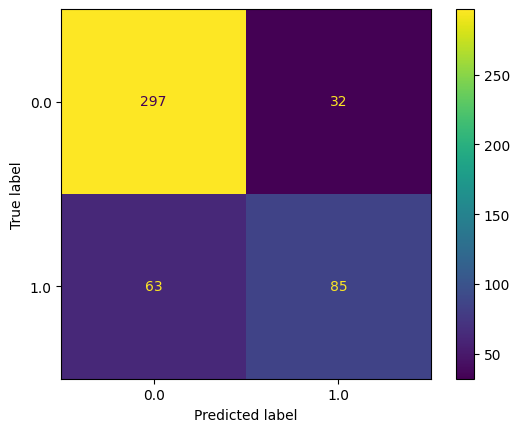

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Random Forest Classifier with balanced class weight**
- Out of all prediction, the measure for correctly predicted 0 is 73% and for 1 is 82% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 90% (Recall)

**As this is imbalanced dataset. We give importance to F1-Score metrics**
- F1 Score of 0 is 64%
- F1 Score of 1 is 86%

**Lets try out bootstrapped random forest using subsample**

In [ ]:
params = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 150, 200],
}

start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced_subsample")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train, y_train)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 4, 'n_estimators': 50}
Best Score:  0.6749244098219145

Elapsed Time:  28.083069324493408


              precision    recall  f1-score   support

         0.0       0.82      0.89      0.86       329
         1.0       0.71      0.57      0.63       148

    accuracy                           0.79       477
   macro avg       0.77      0.73      0.75       477
weighted avg       0.79      0.79      0.79       477



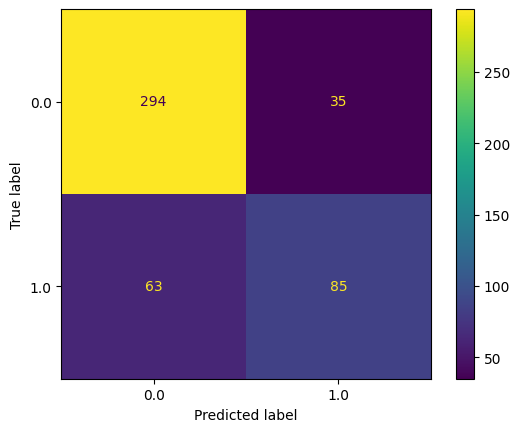

In [ ]:
y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Random Forest Classifier with balanced class weight**
- Out of all prediction, the measure for correctly predicted 0 is 75% and for 1 is 83% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 91% (Recall)

**As this is imbalanced dataset. We give importance to F1-Score metrics**
- F1 Score of 0 is 64%
- F1 Score of 1 is 85%

**There is not much significant difference in the matrices observed for bootstrapped Random Forest and Weighted Random Forest**

## Balancing Dataset using SMOTE

**As the target variable is imbalanced towards 1. We will use SMOTE to balance the dataset**

In [ ]:
from imblearn.over_sampling import SMOTE

print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

sm = SMOTE(random_state = 7)
X_train, y_train = sm.fit_resample(X_train, y_train.ravel())

print('After OverSampling, the shape of train_X: {}'.format(X_train.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train.shape))

print("After OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train == 0)))

Before OverSampling, counts of label '1': 1287
Before OverSampling, counts of label '0': 1287 

After OverSampling, the shape of train_X: (2574, 11)
After OverSampling, the shape of train_y: (2574,) 

After OverSampling, counts of label '1': 1287
After OverSampling, counts of label '0': 1287


## Ensemble Learning: Bagging

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params:  {'max_depth': 3, 'n_estimators': 100}
Best Score:  0.709053031520546

Elapsed Time:  21.58671760559082
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.86       329
         1.0       0.73      0.57      0.64       148

    accuracy                           0.80       477
   macro avg       0.78      0.74      0.75       477
weighted avg       0.80      0.80      0.80       477



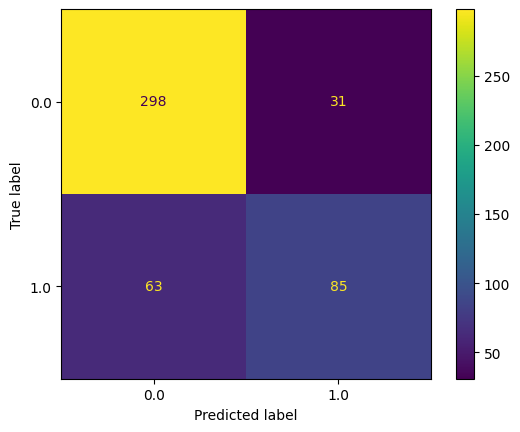

In [ ]:
params = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 150, 200],
}

start_time = time.time()
random_forest = RandomForestClassifier(class_weight="balanced_subsample")
c = GridSearchCV(estimator=random_forest, param_grid=params, n_jobs=-1, cv=3, verbose=True, scoring='f1')

c.fit(X_train, y_train)

print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)
elapsed_time = time.time() - start_time

print("\nElapsed Time: ", elapsed_time)

y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Random Forest Classifier with balanced class weight**
- Out of all prediction, the measure for correctly predicted 0 is 74% and for 1 is 83% (Precision)
- Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 91% (Recall)

**As this is imbalanced dataset. We give importance to F1-Score metrics**
- F1 Score of 0 is 64%
- F1 Score of 1 is 85%

### ROC-AUC Curve

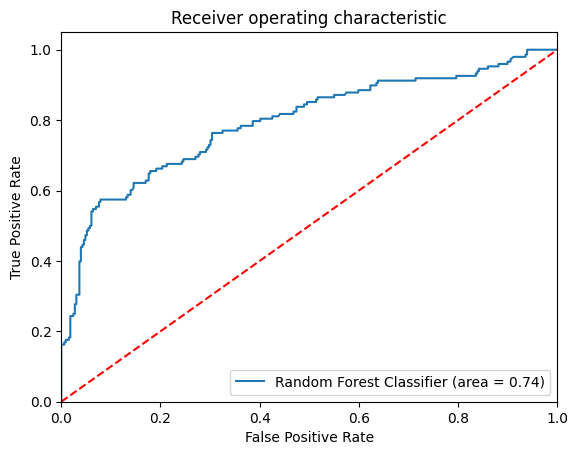

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='Random Forest Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

## Ensemble Learning: Boosting

### Gradient Boosting Classifier

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best Params:  {'learning_rate': 0.2, 'loss': 'log_loss', 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best Score:  0.8181818181818182

 Elapsed Time:  411.03815627098083
              precision    recall  f1-score   support

         0.0       0.83      0.85      0.84       329
         1.0       0.65      0.60      0.62       148

    accuracy                           0.78       477
   macro avg       0.74      0.73      0.73       477
weighted avg       0.77      0.78      0.77       477



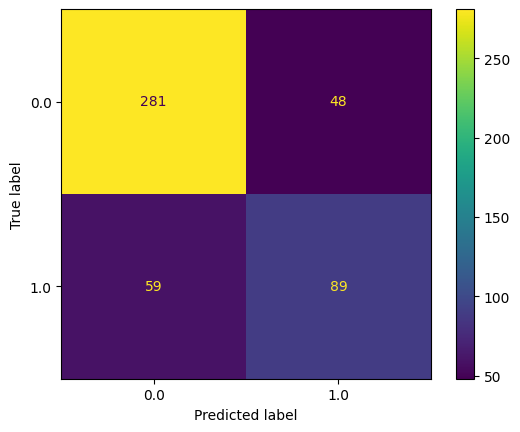

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

params = {
    "max_depth": [2, 3, 4],
    "loss": ["log_loss", "exponential"],
    "subsample": [0.1, 0.2, 0.5, 0.8, 1],
    "learning_rate": [0.1, 0.2, 0.3],
    "n_estimators": [50,100,150,200]
}

gbdt = GradientBoostingClassifier()
start_time = time.time()
c = GridSearchCV(estimator=gbdt, cv=3, n_jobs=-1, verbose=True, param_grid=params)

c.fit(X_train, y_train)
print("Best Params: ", c.best_params_)
print("Best Score: ", c.best_score_)

elapsed_time = time.time() - start_time
print("\n Elapsed Time: ", elapsed_time)

y_pred = c.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=c.classes_).plot()

**Gradient Boosting Classifier Metrics**

Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 82% (Precision)
Out of all actual 0, the measure for correctly predicted is 60% and for 1 is 83% (Recall)

**As this is imbalanced dataset. We give importance to F1-Score metrics**

- F1 Score of 0 is 60%
- F1 Score of 1 is 83%

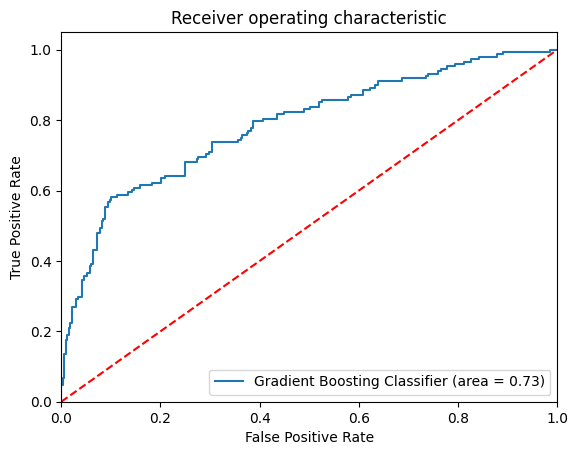

In [229]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='Gradient Boosting Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

### XGBoost Classifier

XGBoost Classifier Score:  0.7631027253668763

               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83       329
         1.0       0.62      0.60      0.61       148

    accuracy                           0.76       477
   macro avg       0.72      0.72      0.72       477
weighted avg       0.76      0.76      0.76       477



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:50:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


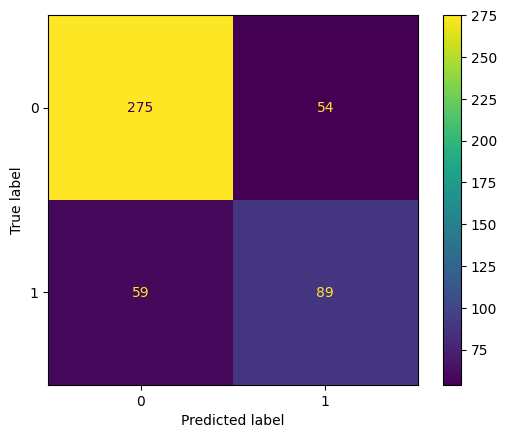

In [231]:
import xgboost as xgb

model = xgb.XGBClassifier(class_weight = "balanced")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("XGBoost Classifier Score: ", model.score(X_test, y_test))
print("\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot()

**XGBoost Classifier with balanced class weight**

Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 81% (Precision)
Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 84% (Recall)

**As this is imbalanced dataset. We give importance to F1-Score metrics**

- F1 Score of 0 is 60%
- F1 Score of 1 is 87%

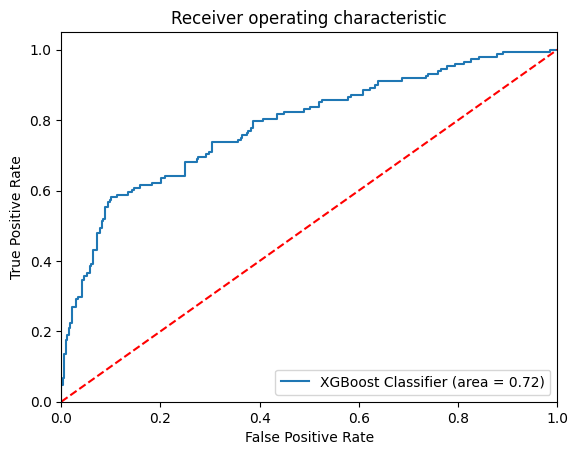

In [232]:
logit_roc_auc=roc_auc_score(y_test,y_pred)
fpr,tpr,thresholds=roc_curve(y_test,c.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr,tpr,label='XGBoost Classifier (area = %0.2f)' % logit_roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

## Final Result Evaluation:
- We observe that we are not getting very high recall on target 0 which may be due to small unbalanced dataset.
- Higher precision means that an algorithm returns more relevant results than irrelevant ones, and high recall means that an algorithm returns most of the relevant results (whether or not irrelevant ones are also returned).
- **We observe that Random Forest with SMOTE outperforms rest of the models and has higher recall and precision values.**
  + The Random Forest method out of all predicted 0 the measure of correctly predicted is 73%, and for 1 it is 82%(Precision).
  + The Random Forest method out of all actual 0 the measure of correctly predicted is 56%, and for 1 it is 91%(Recall).
  + The ROC-AUC curve area for Random Forest Classifier is 0.74
- **Gradient Boosting Classifier Result**
  + Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 82% (Precision)
  + Out of all actual 0, the measure for correctly predicted is 60% and for 1 is 83% (Recall)
  + The ROC-AUC curve area for Gradient Boosting Decision Tree Classifier is 0.71
- **XGBoost Classifier Result**
  + Out of all prediction, the measure for correctly predicted 0 is 62% and for 1 is 81% (Precision)
  + Out of all actual 0, the measure for correctly predicted is 57% and for 1 is 84% (Recall)
  + The ROC-AUC curve area for XGBoost Classifier is 0.71
  
    

## Feature Importance of the best model so far.

**Random Forest Classifier outperforms the rest of the modal.**

**Best parameters**

**Best Params: {'max_depth': 4, 'n_estimators': 50}**

In [233]:
rf = RandomForestClassifier(max_depth = 4, n_estimators= 50, class_weight="balanced")

rf.fit(X_train, y_train)
print("Score of RandomForestClassifier: ", rf.score(X_test, y_test))

Score of RandomForestClassifier:  0.80083857442348


In [234]:
importances = rf.feature_importances_
importances

array([0.02076008, 0.00125778, 0.01738218, 0.00325473, 0.07244162,
       0.07402893, 0.05727424, 0.2208093 , 0.40795498, 0.12255045,
       0.0022857 ])

In [235]:
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

<Figure size 1500x700 with 0 Axes>

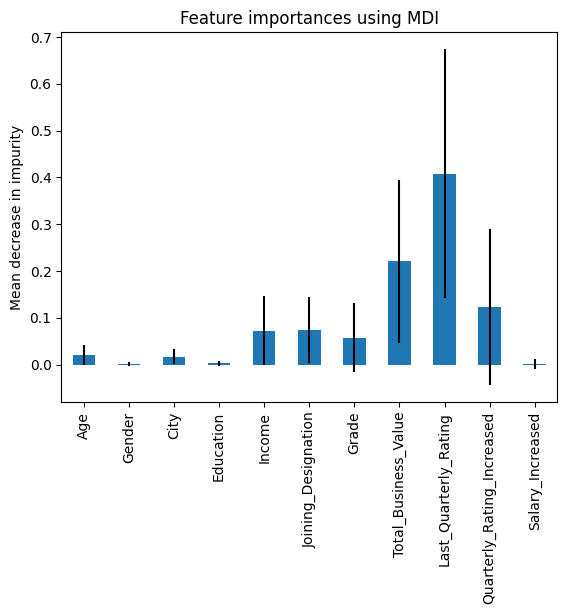

In [236]:
feature_importances = pd.Series(importances, X_train.columns)

plt.figure(figsize=(15,7))
fig, ax = plt.subplots()
feature_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")

plt.show()

**Insights:**

- Last_Quarterly_Rating, Total_Business_Value & Quarterly_Rating_Increased are the most important features.

# Actionable Insights and Recommendation

- Out of 2381 drivers 1616 have left the company.
- We need to incentivise the drivers overtime or other perks to overcome churning
- The employees whose quarterly rating has increased are less likely to leave the organization.
- Company needs to implement the reward system for the customer who provide the feedback and rate drivers
- The employees whose monthly salary has not increased are more likely to leave the organization.
- Company needs to get in touch with those drivers whose monthly salary has not increased and help them out to earn more by provider bonus and perks.
- Out of 2381 employees, 1744 employees had their last quarterly rating as 1.
- Out of 2381 employees, the quarterly rating has not increased for 2076 employees. This is red flag for the company which needs to regulate.
- Company needs to look why customers are not rating drivers.
- Last_Quarterly_Rating, Total_Business_Value & Quarterly_Rating_Increased are the most important features. Company needs to tracks these features as predicators
- We observe that we are not getting very high recall on target 0 which may be due to small unbalanced dataset. More data will overcome this issue.
- The Random Forest Classifier attains the Recall score of 91% for the driver who left the company. Which indicates that model is performing the decent job.